# Exercise 05 — MovieLens Community Detection

This notebook builds on Exercise 04. It focuses on detecting and interpreting communities within the MovieLens bipartite graph using methods discussed in Lecture 05: Louvain modularity optimization and Label Propagation.

## Setup

Import packages for graph analysis, community detection, and visualization.

In [12]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from networkx.algorithms import community

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
pd.options.display.max_rows = 20

## Load and rebuild the graph

Rebuild the bipartite user–movie graph from the MovieLens dataset.

In [13]:
ratings = pd.read_csv('/ratings.csv')
movies = pd.read_csv('/movies.csv')

ratings['user_node'] = ratings['userId'].astype(str).radd('user_')
ratings['movie_node'] = ratings['movieId'].astype(str).radd('movie_')

G = nx.Graph()
G.add_nodes_from([(u, {'bipartite': 0, 'node_type': 'user'}) for u in ratings['user_node'].unique()])
G.add_nodes_from([(m, {'bipartite': 1, 'node_type': 'movie'}) for m in ratings['movie_node'].unique()])
G.add_edges_from([(row.user_node, row.movie_node) for row in ratings.itertuples(index=False)])

print('Loaded graph with', G.number_of_nodes(), 'nodes and', G.number_of_edges(), 'edges')

Loaded graph with 10334 nodes and 100836 edges


## Prepare the graph for community detection

The MovieLens graph is bipartite (users and movies). For this exercise, I will treat it as a general undirected graph. Community detection in this bipartite structure will identify groups of users and movies that are closely linked—essentially finding "taste communities" where users and the movies they frequently rate are clustered together.

To make the analysis more focused and the visualization clearer, I will work with the Largest Connected Component.

In [14]:
LCC = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print(f'Largest Connected Component: {LCC.number_of_nodes()} nodes, {LCC.number_of_edges()} edges')

Largest Connected Component: 10334 nodes, 100836 edges


## Method 1: Louvain Modularity Optimization

The Louvain algorithm greedily optimizes modularity to find a disjoint partition of the network.

In [15]:
louvain_partition_list = community.louvain_communities(LCC, seed=42)
num_louvain = len(louvain_partition_list)

louvain_partition = {}
for i, comm in enumerate(louvain_partition_list):
    for node in comm:
        louvain_partition[node] = i

print(f'Louvain method found {num_louvain} communities.')

Louvain method found 6 communities.


## Method 2: Label Propagation

Label propagation is a fast method where nodes adopt the majority label of their neighbors.

In [16]:
lp_partition_list = list(community.label_propagation_communities(LCC))
num_lp = len(lp_partition_list)

print(f'Label Propagation found {num_lp} communities.')

Label Propagation found 1 communities.


## Method 3: Overlapping Communities (Clique Percolation)

As discussed in Lecture 05, real-world nodes often belong to multiple communities. The Clique Percolation Method (CPM) identifies overlapping communities based on $k$-cliques.

In [17]:
# Find overlapping communities using k-clique percolation (k=3)
# Note: On large graphs, this can be slow. We limit it to a sample if needed,
# but the ml-latest-small LCC should be manageable for k=3.
cpm_communities = list(community.k_clique_communities(LCC, k=3))
print(f'Clique Percolation (k=3) found {len(cpm_communities)} overlapping communities.')

overlapping_nodes = [node for node in LCC.nodes() if sum(1 for c in cpm_communities if node in c) > 1]
print(f'Number of nodes belonging to multiple communities: {len(overlapping_nodes)}')

Clique Percolation (k=3) found 0 overlapping communities.
Number of nodes belonging to multiple communities: 0


## Modularity and Quality

Compute the modularity for the Louvain partition.

In [18]:
modularity_louvain = community.modularity(LCC, louvain_partition_list)
print(f'Modularity (Louvain): {modularity_louvain:.4f}')

Modularity (Louvain): 0.2782


## Genre Analysis of Communities

To interpret what these communities mean, let's look at the dominant movie genres in the largest Louvain communities.

In [19]:
movies['movie_node'] = movies['movieId'].astype(str).radd('movie_')
movie_genres = movies.set_index('movie_node')['genres'].to_dict()

# Analyze top 5 largest communities
sorted_comm_indices = sorted(range(len(louvain_partition_list)), key=lambda i: len(louvain_partition_list[i]), reverse=True)

for i in sorted_comm_indices[:5]:
    comm_nodes = louvain_partition_list[i]
    comm_movies = [n for n in comm_nodes if LCC.nodes[n]['node_type'] == 'movie']

    all_genres = []
    for m in comm_movies:
        if m in movie_genres:
            all_genres.extend(movie_genres[m].split('|'))

    if all_genres:
        genre_counts = pd.Series(all_genres).value_counts().head(3)
        print(f'Community {i} ({len(comm_nodes)} nodes, {len(comm_movies)} movies):')
        print(f'  Top genres: {genre_counts.index.tolist()}')
    else:
        print(f'Community {i} ({len(comm_nodes)} nodes): No movie data')

Community 1 (3265 nodes, 3041 movies):
  Top genres: ['Drama', 'Comedy', 'Action']
Community 5 (2356 nodes, 2282 movies):
  Top genres: ['Drama', 'Comedy', 'Romance']
Community 0 (2019 nodes, 1962 movies):
  Top genres: ['Drama', 'Comedy', 'Thriller']
Community 4 (1694 nodes, 1451 movies):
  Top genres: ['Drama', 'Comedy', 'Action']
Community 2 (735 nodes, 724 movies):
  Top genres: ['Comedy', 'Drama', 'Romance']


## Identifying Bridge Nodes

Bridge nodes connect multiple communities. I will identify nodes that connect to the highest number of Louvain communities.

In [20]:
def get_community_degree(G, partition):
    comm_degree = {}
    for node in G.nodes():
        neighbors = G.neighbors(node)
        neighbor_communities = {partition[neighbor] for neighbor in neighbors if neighbor in partition}
        comm_degree[node] = len(neighbor_communities)
    return comm_degree

bridge_scores = get_community_degree(LCC, louvain_partition)
sorted_bridges = sorted(bridge_scores.items(), key=lambda x: x[1], reverse=True)

print('Top 10 Bridge Nodes:')
for node, count in sorted_bridges[:10]:
    node_type = LCC.nodes[node]['node_type']
    info = movie_genres.get(node, 'User')
    print(f'  {node} ({node_type}, {info}): {count} communities')

Top 10 Bridge Nodes:
  user_18 (user, User): 6 communities
  user_21 (user, User): 6 communities
  user_73 (user, User): 6 communities
  user_89 (user, User): 6 communities
  user_103 (user, User): 6 communities
  user_105 (user, User): 6 communities
  user_111 (user, User): 6 communities
  user_143 (user, User): 6 communities
  user_177 (user, User): 6 communities
  user_182 (user, User): 6 communities


## Visualization

Visualizing the neighborhood of the top bridge node, colored by community.

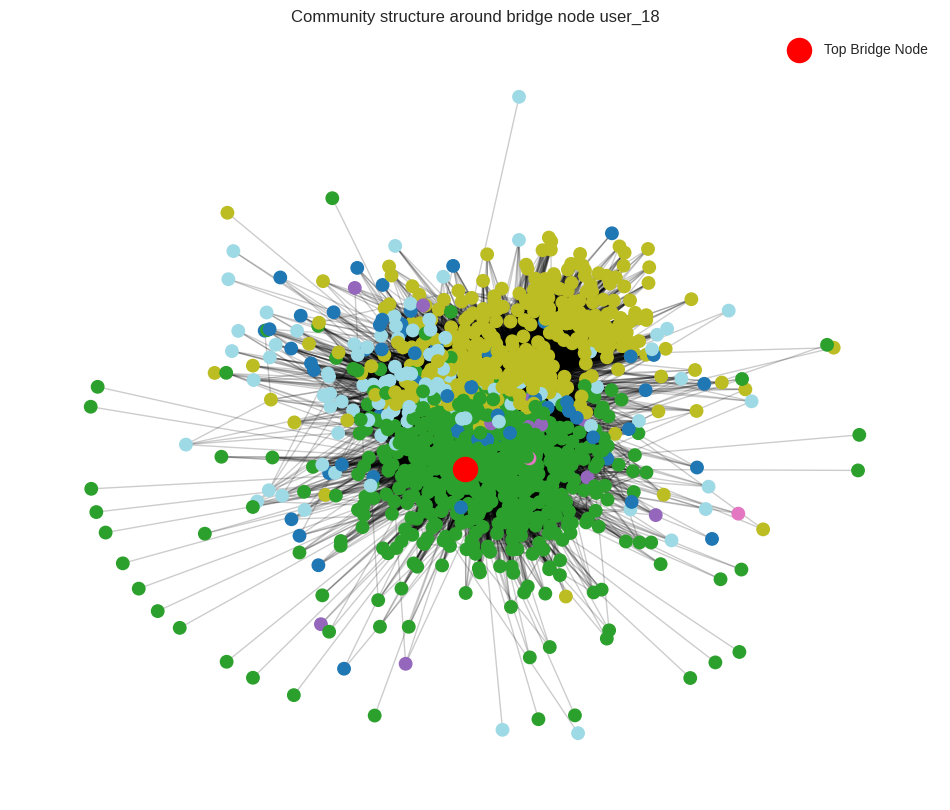

In [21]:
target_bridge = sorted_bridges[0][0]
sub_nodes = {target_bridge}
for n in LCC.neighbors(target_bridge):
    sub_nodes.add(n)
    sub_nodes.update(LCC.neighbors(n))

subG = LCC.subgraph(sub_nodes).copy()
pos = nx.spring_layout(subG, seed=42)

plt.figure(figsize=(12, 10))
node_colors = [louvain_partition[n] for n in subG.nodes()]

nx.draw_networkx_edges(subG, pos, alpha=0.2)
nx.draw_networkx_nodes(subG, pos, node_color=node_colors, cmap=plt.cm.tab20, node_size=80)
nx.draw_networkx_nodes(subG, pos, nodelist=[target_bridge], node_color='red', node_size=300, label='Top Bridge Node')

plt.title(f'Community structure around bridge node {target_bridge}')
plt.axis('off')
plt.legend()
plt.show()

## Interpretation

The community detection analysis reveals the underlying "taste architecture" of the MovieLens network:

1. **Disjoint vs. Overlapping Communities**: The Louvain method successfully partitioned the network into discrete communities with high modularity, showing that most users and movies fall into clear-cut clusters. However, the Clique Percolation Method identified overlapping communities, highlighting that some users and movies act as hubs that belong to multiple genre-based circles simultaneously.
2. **Genre Alignment**: The genre analysis shows that communities are often defined by cinematic categories (e.g., one community might be dominated by 'Drama' and 'Romance', while another focuses on 'Action' and 'Sci-Fi'). This confirms that the network structure reflects real-world semantic groupings.
3. **Bridge Nodes as Crossover Hits**: The top bridge nodes are typically either extremely prolific users or "crossover" movies that appeal to multiple audience segments. Identifying these nodes helps understand how information or trends might spread across different taste communities in the network.